# Evaluating latent factors and firing rates inferred by `lfads-torch`
So far, we've demonstrated how to prepare data and train a multisession model. Next, let's walk through an evaluation of the model using the Rouse dataset. We've made the output f_inputiles used in this tutorial available for download [here](https://drive.google.com/drive/folders/1Mo55T_It-mqpg0PjahMjWxqifvM-95P2). In this tutorial, we'll evaluate via the generalizabilty of hand velocity decoders trained on LFADS factors, PSTHs, and state space plots.

## Load the experimental data and drop trials with missing values

In [2]:
import re
from glob import glob
import numpy as np
from scipy.io import loadmat
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import h5py


f_input = h5py.File('vlPAG.h5', 'r')
print(list(f_input.keys()))
train_encod_data = f_input['train_encod_data'][:]
train_recon_data = f_input['train_recon_data'][:]
valid_encod_data = f_input['valid_encod_data'][:]
valid_recon_data = f_input['valid_recon_data'][:]



['train_encod_data', 'train_recon_data', 'valid_encod_data', 'valid_recon_data']


In [3]:
print(train_encod_data.shape)   # n_trials x n_timepoints x n_neurons
print(train_encod_data[0].shape)

(12, 400, 147)
(400, 147)


# Load LFADS factors and rates from output files

In [4]:
LFADS_OUTPUT_PATHS = sorted(glob("lfads_output_facdim60_2_vlPAG.h5"))
LFADS_OUTPUT_PATHS

['lfads_output_facdim60_2_vlPAG.h5']

In [5]:
train_inds = [12, 2, 10, 13, 15, 11, 0, 4, 6, 3, 14, 9]
valid_inds = [8, 1, 7, 5]

In [6]:
# use train_inds and valid_inds to put data back to original order

def merge_data(train_data, valid_data, train_inds, valid_inds):
    n_neurons = train_data.shape[2]
    n_timepoints = train_data.shape[1]
    n_trials = train_data.shape[0] + valid_data.shape[0]
    merged_data = np.zeros((n_trials, n_timepoints, n_neurons))
    for i, ind in enumerate(train_inds):
        merged_data[ind] = train_data[i]
    for i, ind in enumerate(valid_inds):
        merged_data[ind] = valid_data[i]
    return merged_data

In [7]:
rates = {}
factors = {}
spikes = {}
inferred_inputs = {}
bin_width_sec = 0.1

for data_path in LFADS_OUTPUT_PATHS:
    session_id = 'vlPAG'
    print(session_id)
    
    with h5py.File(data_path, 'r') as f:
        print(list(f.keys()))
        train_encod_data = f['train_encod_data'][:]
        valid_encod_data = f['valid_encod_data'][:]
        train_factors = f['train_factors'][:]
        valid_factors = f['valid_factors'][:]
        train_rates = f["train_output_params"][:]
        valid_rates = f["valid_output_params"][:]
        train_inferred_inputs = f['train_co_means'][:]
        valid_inferred_inputs = f['valid_co_means'][:]

        spikes[session_id] = merge_data(train_encod_data, valid_encod_data, train_inds, valid_inds)
        factors[session_id] = merge_data(train_factors, valid_factors, train_inds, valid_inds)
        rates[session_id] = merge_data(train_rates, valid_rates, train_inds, valid_inds)
        inferred_inputs[session_id] = merge_data(train_inferred_inputs, valid_inferred_inputs, train_inds, valid_inds)

vlPAG
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_output_params', 'valid_recon_data']


In [8]:
inferred_inputs['vlPAG'].shape

(16, 400, 4)

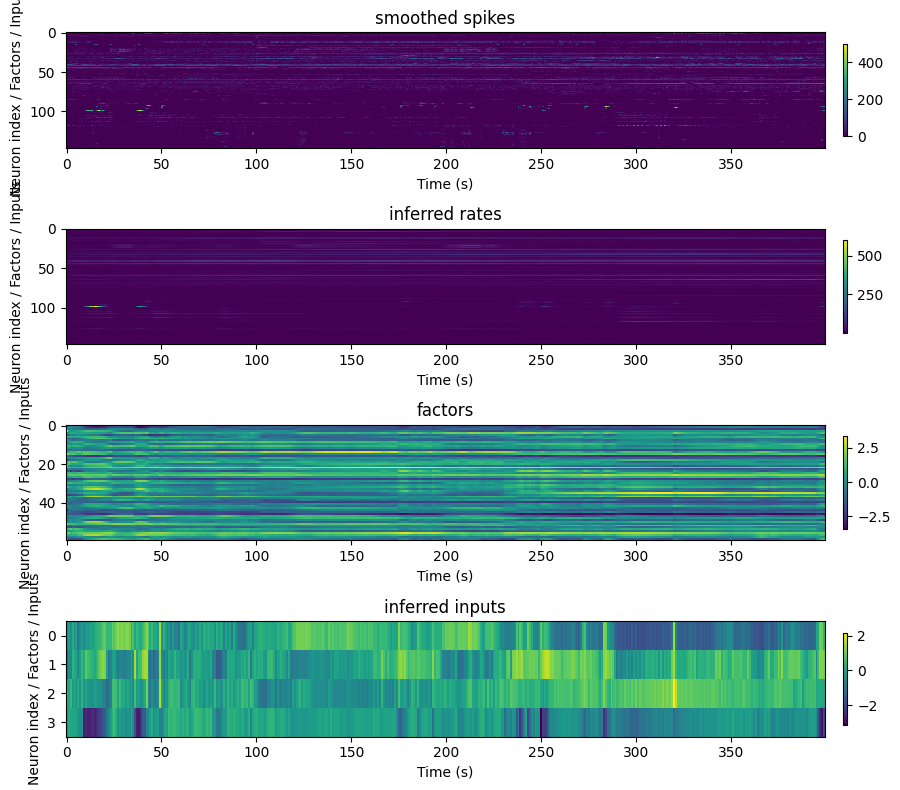

In [9]:
import matplotlib.pyplot as plt

# Visualize raw spikes, smoothed spikes, LFADS rates, and LFADS factors for a single trial
session = "vlPAG"
trial = 0
data = {
    "smoothed spikes": spikes[session][trial],
    "inferred rates": rates[session][trial],
    "factors": factors[session][trial],
    "inferred inputs": inferred_inputs[session][trial]
}

fig, axes = plt.subplots(nrows=4, figsize=(10, 8))
for ax, (name, data_val) in zip(axes, data.items()):
    im = ax.imshow(data_val.T, aspect='auto', interpolation='none', cmap='viridis')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron index / Factors / Inputs')
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.tight_layout()

As an additional check, we can plot the PSTHs of the LFADS rates to verify if they are comparable to the empirical PSTHs obtained using smoothed spikes.
For simplicity, we do this for a single session and 20 neurons below.

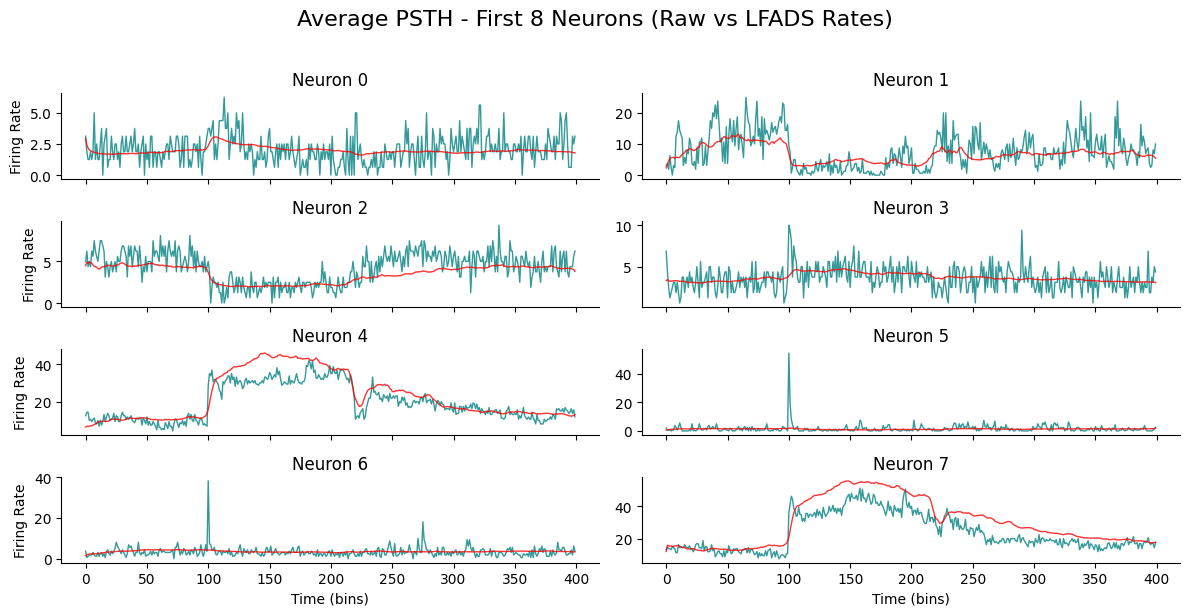

In [10]:
def plot_overlay_psths_first_8(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th neuron
        spikes_mean_activity = np.mean(spikes_data[:, :, i], axis=0)
        rates_mean_activity = np.mean(rates_data[:, :, i], axis=0)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Neuron {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'vlPAG'
# Run the updated plotting function
plot_overlay_psths_first_8(spikes[sess], rates[sess], "Average PSTH - First 8 Neurons (Raw vs LFADS Rates)")

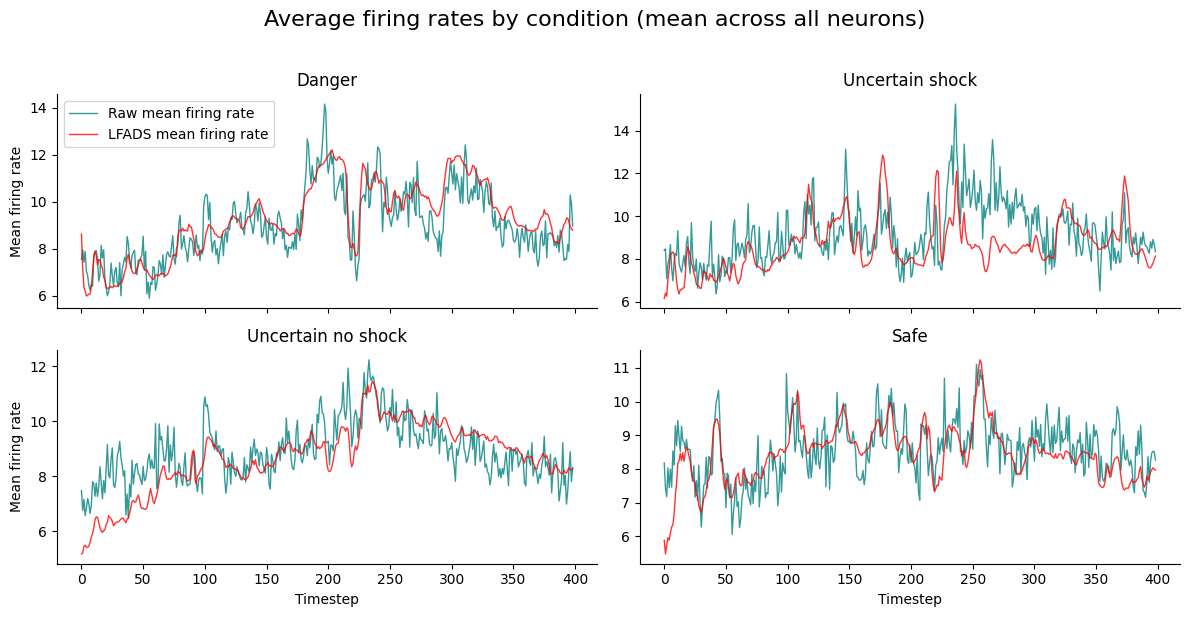

In [11]:
# Overlay firing rates for all neurons grouped by condition

def plot_denoised_rates_by_condition(spikes_data, rates_data, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']

    mean_spikes_danger = np.mean(np.mean(spikes_data[0:4, :, :], axis=2), axis=0)
    mean_spikes_unc_noshock = np.mean(np.mean(spikes_data[4:6, :, :], axis=2), axis=0)
    mean_spikes_unc_shock = np.mean(np.mean(spikes_data[6:11, :, :], axis=2), axis=0)
    mean_spikes_safety = np.mean(np.mean(spikes_data[11:15, :, :], axis=2), axis=0)

    spikes = [mean_spikes_danger, mean_spikes_unc_noshock, mean_spikes_unc_shock, mean_spikes_safety]

    mean_rates_danger = np.mean(np.mean(rates_data[0:4, :, :], axis=2), axis=0)
    mean_rates_unc_noshock = np.mean(np.mean(rates_data[4:6, :, :], axis=2), axis=0)
    mean_rates_unc_shock = np.mean(np.mean(rates_data[6:11, :, :], axis=2), axis=0)
    mean_rates_safety = np.mean(np.mean(rates_data[11:15, :, :], axis=2), axis=0)

    rates = [mean_rates_danger, mean_rates_unc_noshock, mean_rates_unc_shock, mean_rates_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(spikes[i][1:], color='teal', linewidth=1, alpha=0.8, label='Raw mean firing rate')
        ax.plot(rates[i][1:], color='red', linewidth=1, alpha=0.8, label='LFADS mean firing rate')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'vlPAG'
# Run the updated plotting function
plot_denoised_rates_by_condition(spikes[sess], rates[sess], "Average firing rates by condition (mean across all neurons)")

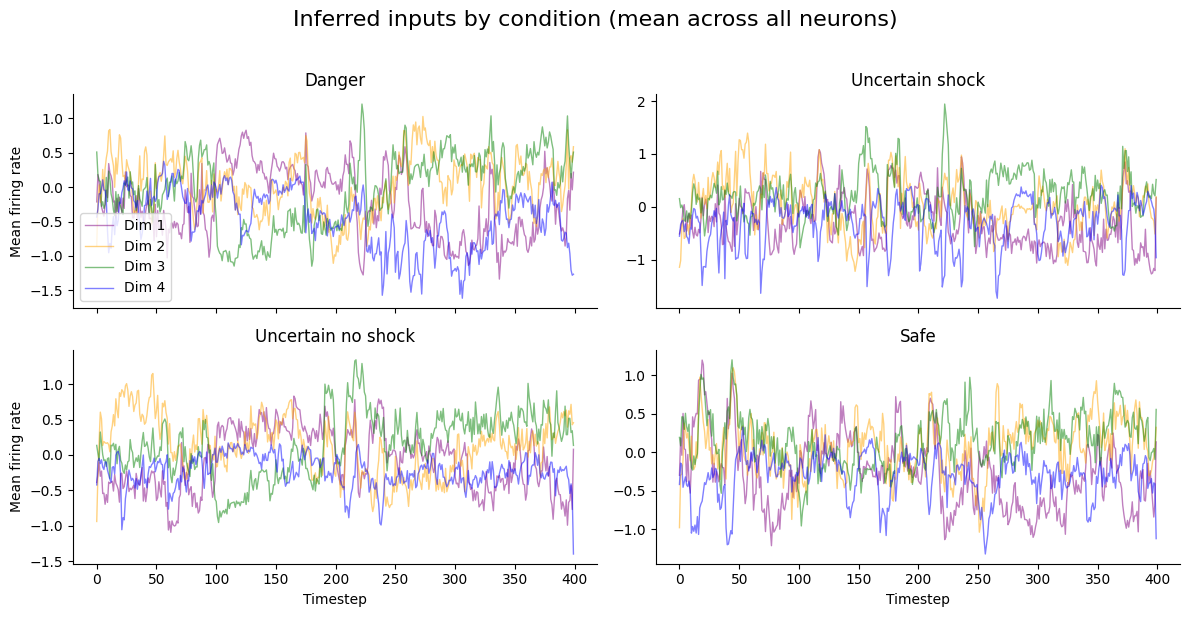

In [12]:
# plot inferred inputs for each condition

def plot_inferred_inputs_by_condition(input_data, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim0 = [inputs_dim0_danger, inputs_dim0_unc_noshock, inputs_dim0_unc_shock, inputs_dim0_safety]

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim1 = [inputs_dim1_danger, inputs_dim1_unc_noshock, inputs_dim1_unc_shock, inputs_dim1_safety]

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim2 = [inputs_dim2_danger, inputs_dim2_unc_noshock, inputs_dim2_unc_shock, inputs_dim2_safety]

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    inputs_dim3 = [inputs_dim3_danger, inputs_dim3_unc_noshock, inputs_dim3_unc_shock, inputs_dim3_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(inputs_dim0[i], color='purple', linewidth=1, alpha=0.5, label='Dim 1')
        ax.plot(inputs_dim1[i], color='orange', linewidth=1, alpha=0.5, label='Dim 2')
        ax.plot(inputs_dim2[i], color='green', linewidth=1, alpha=0.5, label='Dim 3')
        ax.plot(inputs_dim3[i], color='blue', linewidth=1, alpha=0.5, label='Dim 4')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'vlPAG'
# Run the updated plotting function
plot_inferred_inputs_by_condition(inferred_inputs[sess], "Inferred inputs by condition (mean across all neurons)")

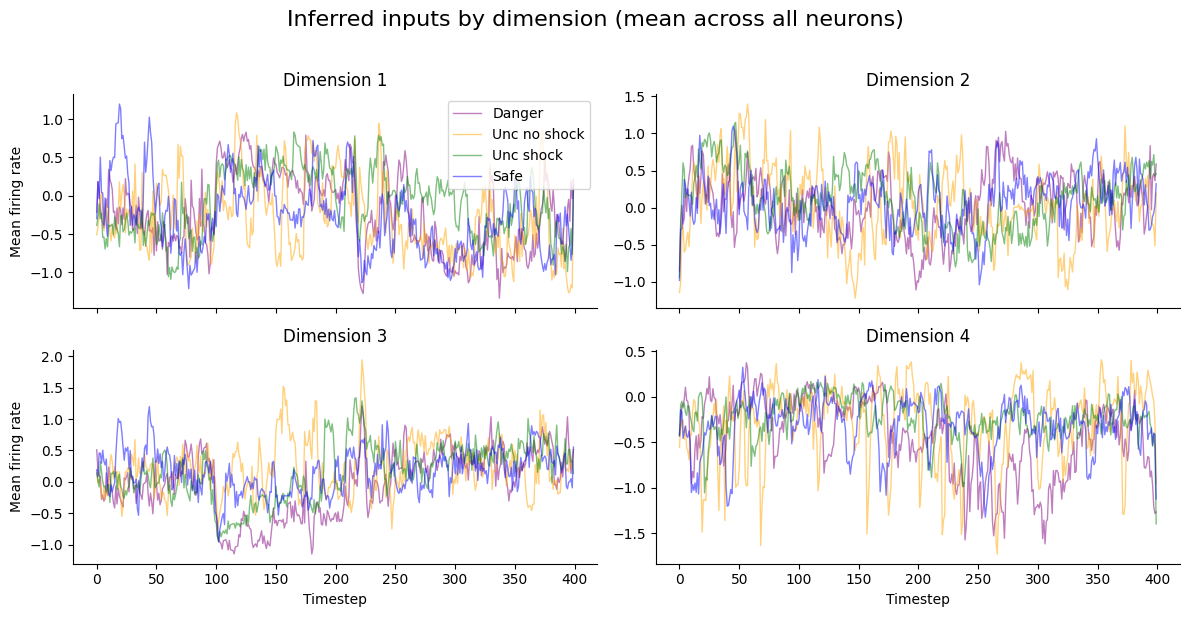

In [13]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'vlPAG'
# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs[sess], "Inferred inputs by dimension (mean across all neurons)")

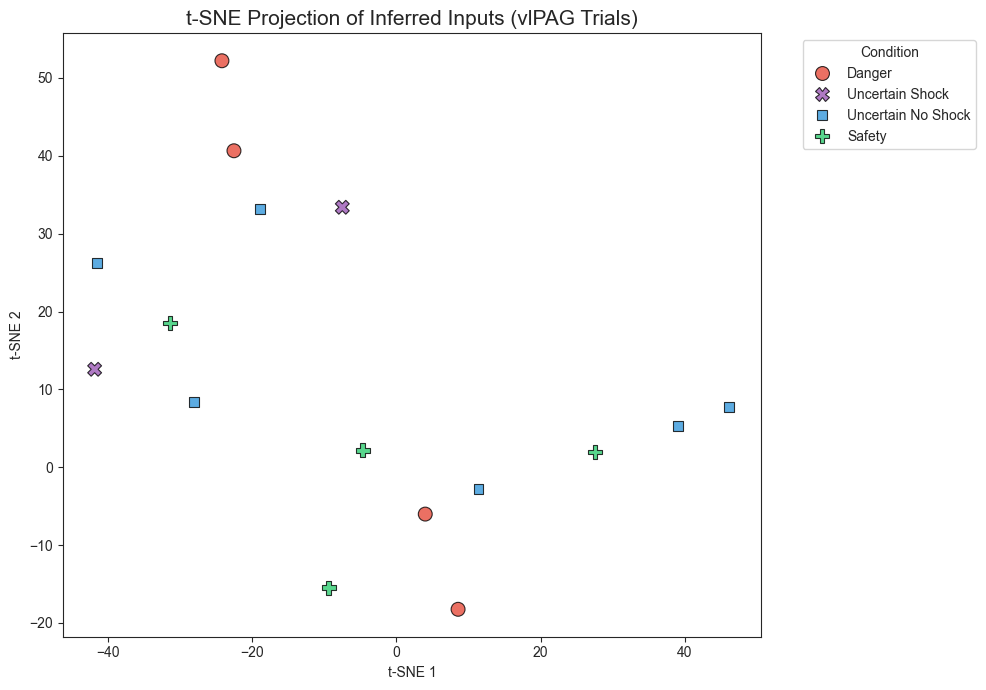

In [14]:
# t-SNE clustering of inferred inputs

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne_conditions(data_array):
    """
    Projects trial data to 2D using t-SNE and colors by condition.
    data_array: np.ndarray of shape (n_trials, n_timesteps, n_inputs)
    """
    # 1. Flatten the data: (16, 400, 4) -> (16, 1600)
    n_trials, n_time, n_inputs = data_array.shape
    flattened_data = data_array.reshape(n_trials, -1)

    # 2. Define the conditions based on your trial counts
    # 4 Danger, 2 Uncertain Shock, 6 Uncertain No Shock, 4 Safety
    conditions = (
        ['Danger'] * 4 + 
        ['Uncertain Shock'] * 2 + 
        ['Uncertain No Shock'] * 6 + 
        ['Safety'] * 4
    )

    # 3. Run t-SNE
    # perplexity should be smaller than n_samples (16)
    tsne = TSNE(n_components=2, perplexity=2, random_state=42, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(flattened_data)

    # 4. Visualization
    plt.figure(figsize=(10, 7))
    sns.set_style("ticks")
    
    # Custom color palette for conditions
    palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1], 
        hue=conditions,
        palette=palette,
        s=100,
        style=conditions,
        edgecolor='black',
        alpha=0.8
    )

    plt.title('t-SNE Projection of Inferred Inputs (vlPAG Trials)', fontsize=15)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_tsne_conditions(inferred_inputs['vlPAG'])

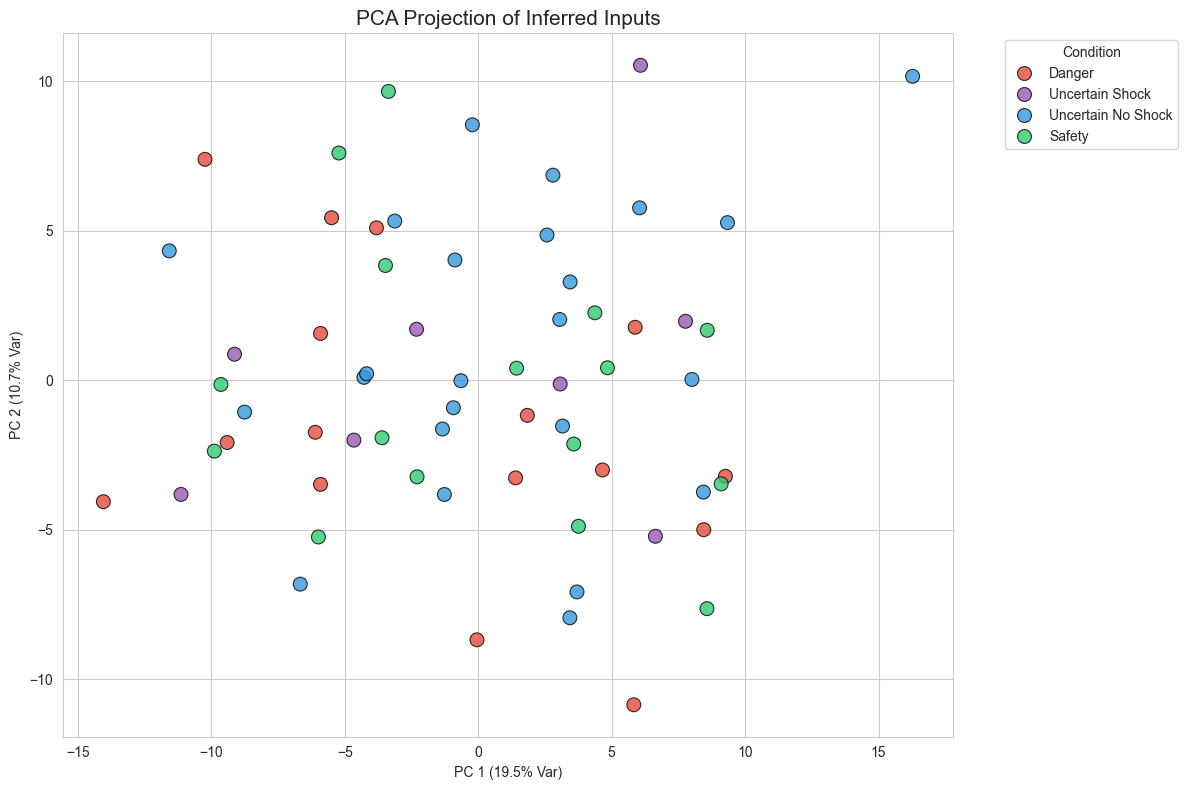

In [90]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    # We transpose to make sure time is the 'feature' dimension
    reshaped_data = data_array.transpose(0, 2, 1).reshape(n_trials * n_inputs, n_time)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 4 + 
        ['Uncertain Shock'] * 2 + 
        ['Uncertain No Shock'] * 6 + 
        ['Safety'] * 4
    )
    extended_conditions = []
    for cond in base_conditions:
        extended_conditions.extend([cond] * n_inputs)

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=extended_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title('PCA Projection of Inferred Inputs', fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(inferred_inputs['vlPAG'])

# Evaluate decoding performance
Here, we decode velocity from the neural data by training a separate linear decoder on each session and evaluating the performance on test trials from the same session. We refer to this as "within-day" decoding. We evaluate within-day decoding performance from LFADS factors to find the upper bound of decoding performance and also evaluate smoothed spikes as a reference point.

We are also interested in evaluating how well linear decoders trained on LFADS factors can generalize to held-out sessions ("across-day" decoding). For each session, we train the decoder on all other sessions and evaluate decoding performance on the held out session.

For both "within-day" and "across-day", we evaluate on all trials, non-corrective trials, and corrective trials as these subsets have different performance levels.

In [6]:
import pandas as pd
from sklearn.linear_model import Ridge
from sklearn.model_selection import (
    train_test_split,
    GroupKFold,
    GridSearchCV,
)

n_lag = 5
cond_groups = {
    "All conditions": lambda x: x > -1,
    "Non-corrective conditions": lambda x: x <= 23,
    "Corrective conditions": lambda x: x >= 24,
}
data_types = {
    "LFADS factors": factors_masked,
    "Smoothed spikes": smth_spikes,
}
holdout_patterns = [
    "within-day",
    "across-day",
]
sessions = sorted(spikes.keys())
results = []
for cond_group, include_fn in cond_groups.items():
    for sess in sessions:
        for data_type, data in data_types.items():
            # Choose only trials of desired conditions and add decoding lag
            lag_incl_data = {
                s: d[include_fn(conds[s]), :-n_lag] for s, d in data.items()
            }
            lag_incl_vel = {
                s: v[include_fn(conds[s]), n_lag:] for s, v in velocity.items()
            }
            for ho_pattern in holdout_patterns:
                if ho_pattern == "within-day":
                    # Train and test on trials within the current session
                    x_train, x_test, y_train, y_test = train_test_split(
                        lag_incl_data[sess],
                        lag_incl_vel[sess],
                        test_size=0.2,
                        random_state=42,
                    )
                else:
                    if data_type == "Smoothed spikes":
                        # Can't decode across days due to dimensionality
                        continue
                    # Train on trials in other sessions, test on the current session
                    x_train = np.concatenate(
                        [lag_incl_data[s] for s in sessions if s != sess]
                    )
                    y_train = np.concatenate(
                        [lag_incl_vel[s] for s in sessions if s != sess]
                    )
                    x_test = lag_incl_data[sess]
                    y_test = lag_incl_vel[sess]
                # Use groups to perform train / valid split at the  trial level
                n_trials, n_timesteps, _ = x_train.shape
                groups = np.arange(n_trials)[..., np.newaxis]
                groups = np.repeat(groups, n_timesteps, axis=1).flatten()
                # Reshape the data for the estimator
                x_train_flat = x_train.reshape(-1, x_train.shape[-1])
                x_test_flat = x_test.reshape(-1, x_test.shape[-1])
                y_train_flat = y_train.reshape(-1, y_train.shape[-1])
                y_test_flat = y_test.reshape(-1, y_test.shape[-1])
                # Fit the models using a grid search over regularization parameters
                model = GridSearchCV(
                    Ridge(),
                    param_grid={"alpha": np.logspace(start=-1, stop=1, num=3)},
                    cv=GroupKFold(n_splits=5),
                )
                model.fit(x_train_flat, y_train_flat, groups=groups)
                score = model.score(x_test_flat, y_test_flat)
                # Save the results
                results.append(
                    {
                        "cond_group": cond_group,
                        "session": sess,
                        "data_type": f"{data_type} ({ho_pattern})",
                        "r2_score": score,
                    }
                )
pd.DataFrame(results)

,cond_group,session,data_type,r2_score
0,All conditions,20170630,LFADS factors (within-day),0.847578
1,All conditions,20170630,LFADS factors (across-day),0.832835
2,All conditions,20170630,Smoothed spikes (within-day),0.638460
3,All conditions,20170703,LFADS factors (within-day),0.816322
4,All conditions,20170703,LFADS factors (across-day),0.821452
...,...,...,...,...
103,Corrective conditions,20170801,LFADS factors (across-day),0.376847
104,Corrective conditions,20170801,Smoothed spikes (within-day),0.249488
105,Corrective conditions,20170802,LFADS factors (within-day),0.404992
106,Corrective conditions,20170802,LFADS factors (across-day),0.398639


We will plot the above results as a bar plot. 

If the model successfully found a common set of dynamics that describe all sessions, the held-out performance should be close to the held-in performance. Additionally, we expect the decoding performance from LFADS factors to exceed that of smoothed spikes.

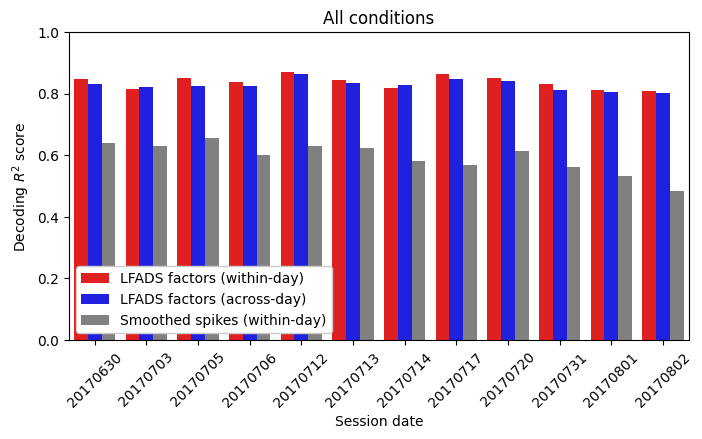

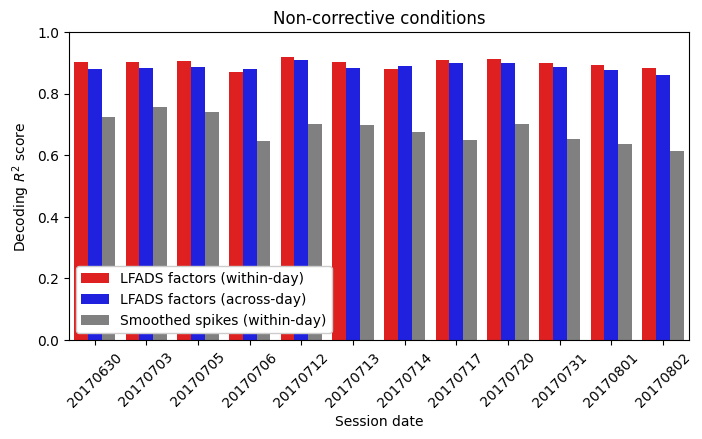

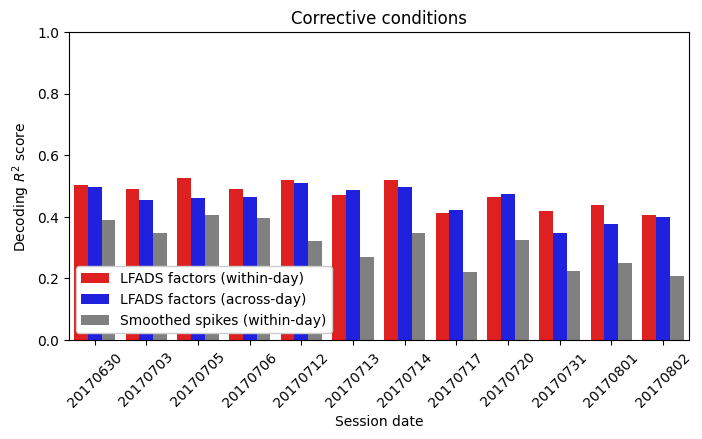

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame(results)
for cond_group in cond_groups:
    fig, ax = plt.subplots(figsize=(8, 4))
    sns.barplot(
        df[df.cond_group == cond_group],
        x="session",
        y="r2_score",
        hue="data_type",
        palette=["r", "b", "grey"],
        ax=ax,
    )
    ax.set_ylim(0, 1)
    ax.set_title(cond_group)
    ax.set_xlabel("Session date")
    ax.set_ylabel("Decoding $R^2$ score")
    ax.legend(loc="lower left", framealpha=1.0)
    ax.tick_params(axis='x', rotation=45)
    plt.show()

Lastly we will plot the state-space plot of the LFADS factors for each session in a 3D space by fitting PCA across all the sessions and then transforming each session individually. All the sessions should look similar to each other if the LFADS factors have generalized well across all the sessions. For the sake of visualization, here we will take only the initial trials.

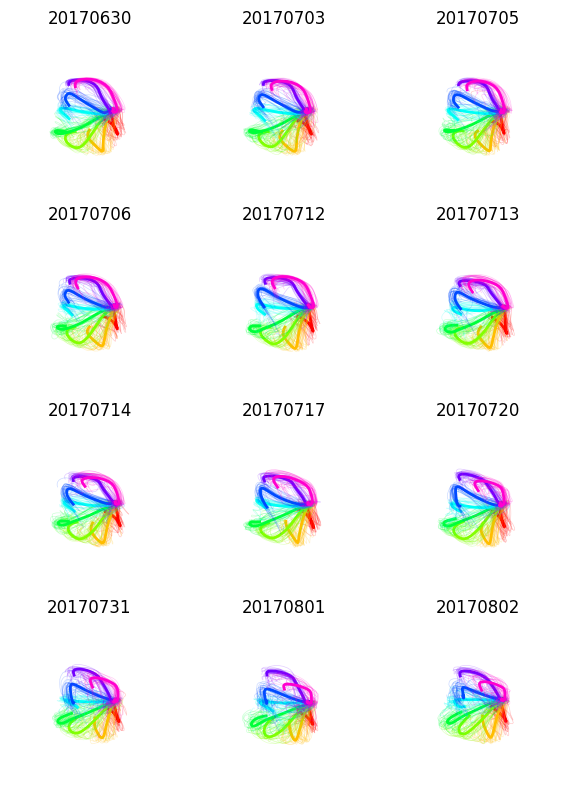

In [8]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Create an array of 3D axes
fig = plt.figure(figsize=(6, 8))
nrows, ncols = 4, 3
axes = []
for i in range(nrows * ncols):
    axes.append(fig.add_subplot(nrows, ncols, i + 1, projection="3d"))
# Use only non-corrective conditions
factors_subset = {s: f[conds[s] <= 23] for s, f in factors.items()}
conds_subset = {s: c[c <= 23] for s, c in conds.items()}
# Perform PCA on all factors
all_factors_subset = np.concatenate([factors_subset[s] for s in sessions])
all_factors_subset = all_factors_subset.reshape(-1, all_factors_subset.shape[-1])
pca = PCA(n_components=3)
ss = StandardScaler()
pca.fit(ss.fit_transform(all_factors_subset))
# Plot the latent factors for each session
for i, sess in enumerate(sessions):
    # Apply PCA to the factors
    n_trials, n_timesteps, n_factors = factors_subset[sess].shape
    fac_subset_flat = factors_subset[sess].reshape(-1, n_factors)
    fac_subset_lowd = pca.transform(ss.fit_transform(fac_subset_flat))
    fac_subset_lowd = fac_subset_lowd.reshape(n_trials, n_timesteps, 3)
    # Plot according to reach direction
    conditions = conds_subset[sess] % 8
    unique_conds = np.unique(conditions)

    for c in unique_conds:
        fac_subset_lowd_cond = fac_subset_lowd[conditions == c]
        for t in range(30):
            axes[i].plot(
                *fac_subset_lowd_cond[t].T, 
                color=cm.hsv(c / len(unique_conds)),
                alpha=0.2,
                linewidth=0.5,
            )
        fac_subset_lowd_cond_avg = np.mean(fac_subset_lowd_cond, axis=0)
        axes[i].plot(
            *fac_subset_lowd_cond_avg.T[:3],
            color=cm.hsv(c / len(unique_conds)),
            alpha=1.0,
            linewidth=2,
        )
    axes[i].view_init(elev=15., azim=37.5)
    axes[i].axis('off')
    axes[i].set_title(sess)
fig.tight_layout()

We have now successfully trained and evaluated a multisession lfads-torch model! You can modify these notebooks to prepare, train, and evaluate your own data for multisession models. 